# 📊 Grau de Vértices e Teoremas

**Conteúdo:** Grau de vértices, Teorema do Aperto de Mãos (Handshaking), grafos regulares.

---

In [9]:
# Importando bibliotecas
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
%matplotlib inline

## 1. Grau de um Vértice (Grafo Não Dirigido)

### 📚 Definição:

O **grau de um vértice** $v$, denominado $\text{grau}(v)$ ou $\deg(v)$, é igual ao:
- **Número de arestas incidentes a** $v$
- **Laços contam duas vezes** (entram e saem do mesmo vértice)

### Grau Total:
O **grau total de** $G$ é a **soma dos graus de todos os vértices**:
$$\text{Grau Total} = \sum_{v \in V} \deg(v)$$

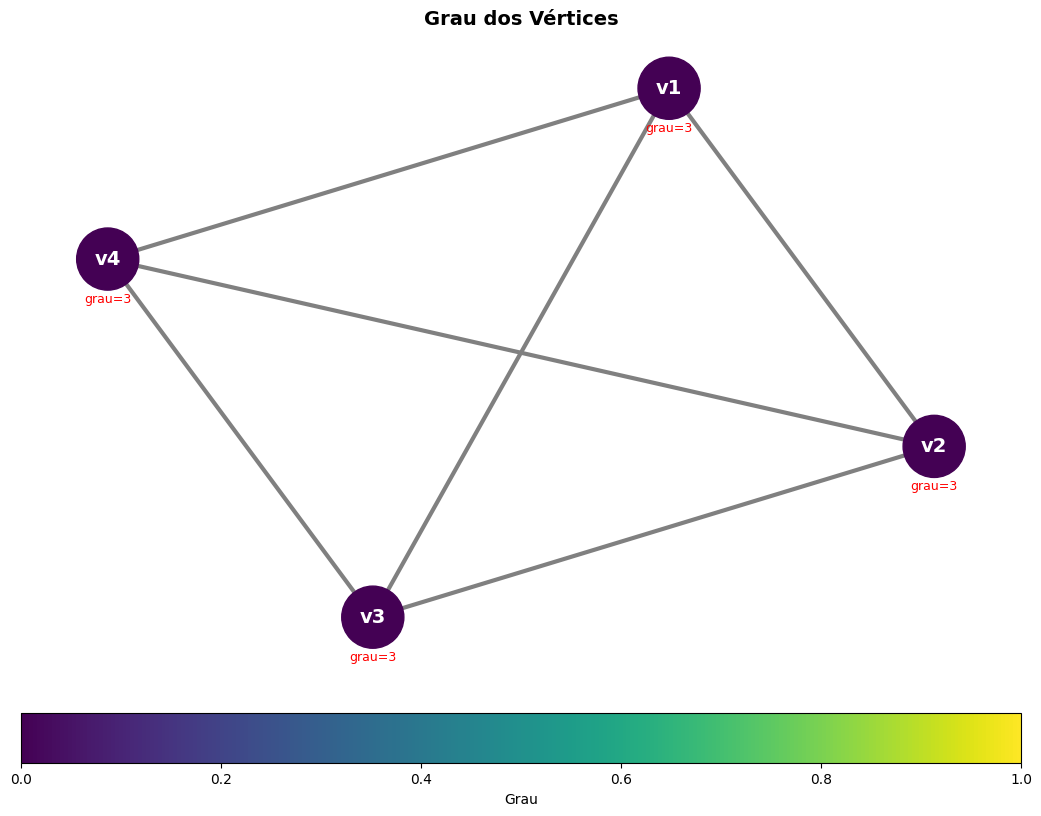

Graus dos vértices:
  v1: grau = 3
  v2: grau = 3
  v3: grau = 3
  v4: grau = 3

Grau Total do Grafo: 12
Número de arestas: 6
Relação: Grau Total = 2 × Número de Arestas = 2 × 6 = 12


In [10]:
# Exemplo: Calculando o grau de vértices
G = nx.Graph()
G.add_edges_from([
    ('v1', 'v2'), ('v1', 'v3'), ('v1', 'v4'),
    ('v2', 'v3'), ('v2', 'v4'),
    ('v3', 'v4')
])

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42)

# Calculando graus
graus = dict(G.degree())

# Cor dos nós baseada no grau
node_colors = [graus[v] for v in G.nodes()]

nx.draw(G, pos,
        with_labels=True,
        node_color=node_colors,
        node_size=2000,
        cmap=plt.cm.viridis,
        font_size=14,
        font_weight='bold',
        font_color='white',
        edge_color='gray',
        width=3)

# Adicionar graus como rótulos
labels_grau = {v: f"grau={graus[v]}" for v in G.nodes()}
pos_labels = {k: (v[0], v[1]-0.15) for k, v in pos.items()}
nx.draw_networkx_labels(G, pos_labels, labels_grau, 
                        font_size=9, font_color='red')

plt.title('Grau dos Vértices', fontsize=14, fontweight='bold')
plt.colorbar(plt.cm.ScalarMappable(cmap=plt.cm.viridis), 
             ax=plt.gca(), label='Grau', orientation='horizontal', pad=0.05)
plt.axis('off')
plt.tight_layout()
plt.show()

print("Graus dos vértices:")
for v, grau in graus.items():
    print(f"  {v}: grau = {grau}")

grau_total = sum(graus.values())
print(f"\nGrau Total do Grafo: {grau_total}")
print(f"Número de arestas: {G.number_of_edges()}")
print(f"Relação: Grau Total = 2 × Número de Arestas = 2 × {G.number_of_edges()} = {2 * G.number_of_edges()}")

---

## 2. Grau de um Vértice (Grafo Dirigido)

### 📚 Definição:

Em um **grafo dirigido**, o grau de um vértice $v$ é:
- **Grau de saída** (*out-degree*): Número de arestas que **saem** de $v$
- **Grau de entrada** (*in-degree*): Número de arestas que **chegam** em $v$
- **Grau total**: $\deg(v) = \text{in-deg}(v) + \text{out-deg}(v)$

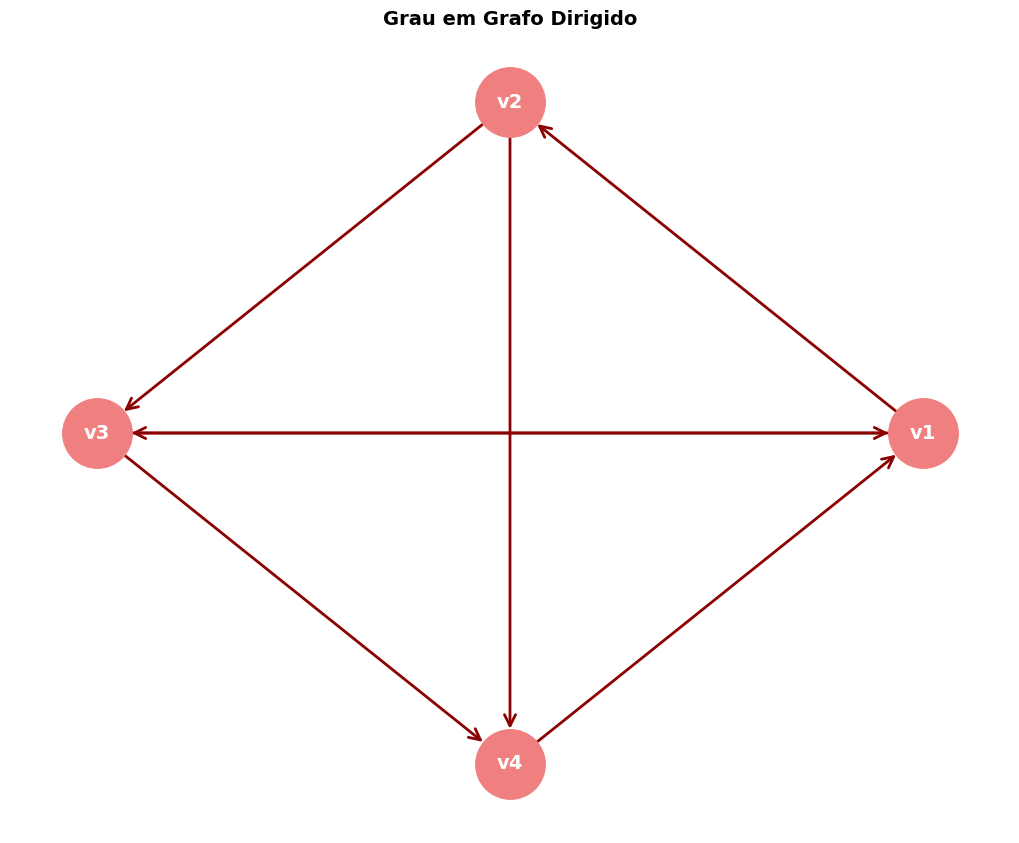

Graus dos vértices (Grafo Dirigido):
Vértice    | In-Degree    | Out-Degree   | Total
v1         | 2            | 2            | 4
v2         | 1            | 2            | 3
v3         | 2            | 2            | 4
v4         | 2            | 1            | 3

Exemplo: v3 tem:
  • In-degree = 2 (arestas chegando: v1→v3, v2→v3)
  • Out-degree = 2 (arestas saindo: v3→v1, v3→v4)
  • Grau total = 4


In [11]:
# Exemplo com grafo dirigido
D = nx.DiGraph()
D.add_edges_from([
    ('v1', 'v2'), ('v1', 'v3'),
    ('v2', 'v3'), ('v2', 'v4'),
    ('v3', 'v1'), ('v3', 'v4'),
    ('v4', 'v1')
])

plt.figure(figsize=(10, 8))
pos = nx.circular_layout(D)

nx.draw(D, pos,
        with_labels=True,
        node_color='lightcoral',
        node_size=2500,
        font_size=14,
        font_weight='bold',
        font_color='white',
        edge_color='darkred',
        width=2,
        arrows=True,
        arrowsize=20,
        arrowstyle='->')

plt.title('Grau em Grafo Dirigido', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print("Graus dos vértices (Grafo Dirigido):")
print("=" * 60)
print(f"{'Vértice':<10} | {'In-Degree':<12} | {'Out-Degree':<12} | {'Total'}")
print("=" * 60)

for v in D.nodes():
    in_deg = D.in_degree(v)
    out_deg = D.out_degree(v)
    total = in_deg + out_deg
    print(f"{v:<10} | {in_deg:<12} | {out_deg:<12} | {total}")

print("\nExemplo: v3 tem:")
print(f"  • In-degree = {D.in_degree('v3')} (arestas chegando: v1→v3, v2→v3)")
print(f"  • Out-degree = {D.out_degree('v3')} (arestas saindo: v3→v1, v3→v4)")
print(f"  • Grau total = {D.in_degree('v3') + D.out_degree('v3')}")

---

## 3. Teorema do Aperto de Mãos (Handshaking Theorem)

### 🎓 Teorema:

Seja $G$ um grafo. A **soma dos graus de todos os vértices** de $G$ é **duas vezes o número de arestas** de $G$.

### Fórmula:
$$\sum_{v \in V} \deg(v) = 2|E|$$

Especificamente, se os vértices de $G$ são $v_1, v_2, \ldots, v_n$:
$$\deg(v_1) + \deg(v_2) + \cdots + \deg(v_n) = 2 \times |E|$$

### 💡 Intuição:
Cada aresta **contribui 2** para o grau total (1 para cada vértice terminal).

In [12]:
# Demonstração prática do Teorema do Aperto de Mãos
print("🎓 TEOREMA DO APERTO DE MÃOS - Verificação Prática\n")
print("=" * 60)

# Testando com diferentes grafos
grafos_teste = [
    ("Grafo Simples", nx.Graph([(1,2), (2,3), (3,4), (4,1), (1,3)])),
    ("Grafo Completo K4", nx.complete_graph(4)),
    ("Grafo Ciclo C5", nx.cycle_graph(5)),
    ("Grafo Roda W4", nx.wheel_graph(5))
]

for nome, G in grafos_teste:
    graus = dict(G.degree())
    soma_graus = sum(graus.values())
    num_arestas = G.number_of_edges()
    dois_vezes_arestas = 2 * num_arestas
    
    print(f"\n{nome}:")
    print(f"  Graus: {list(graus.values())}")
    print(f"  Soma dos graus: {soma_graus}")
    print(f"  2 × # arestas: 2 × {num_arestas} = {dois_vezes_arestas}")
    print(f"  ✓ Teorema verificado: {soma_graus == dois_vezes_arestas}")

print("\n" + "=" * 60)
print("Em TODOS os grafos: Σ graus = 2 × |E| ✓")

🎓 TEOREMA DO APERTO DE MÃOS - Verificação Prática


Grafo Simples:
  Graus: [3, 2, 3, 2]
  Soma dos graus: 10
  2 × # arestas: 2 × 5 = 10
  ✓ Teorema verificado: True

Grafo Completo K4:
  Graus: [3, 3, 3, 3]
  Soma dos graus: 12
  2 × # arestas: 2 × 6 = 12
  ✓ Teorema verificado: True

Grafo Ciclo C5:
  Graus: [2, 2, 2, 2, 2]
  Soma dos graus: 10
  2 × # arestas: 2 × 5 = 10
  ✓ Teorema verificado: True

Grafo Roda W4:
  Graus: [4, 3, 3, 3, 3]
  Soma dos graus: 16
  2 × # arestas: 2 × 8 = 16
  ✓ Teorema verificado: True

Em TODOS os grafos: Σ graus = 2 × |E| ✓


---

## 4. Corolário: Número Par de Vértices de Grau Ímpar

### 🎓 Teorema:

**Em qualquer grafo $G$, existe um número PAR de vértices de grau ímpar.**

### Prova (resumo):
- Seja $P$ = soma dos graus pares (é par)
- Seja $I$ = soma dos graus ímpares
- Grau Total $T = P + I$
- Pelo Teorema do Aperto de Mãos, $T = 2|E|$ (é par)
- Como $T$ é par e $P$ é par, então $I = T - P$ é par
- Se $I$ (soma de $n$ inteiros ímpares) é par, então $n$ deve ser par ✓

In [13]:
# Verificação: Número de vértices de grau ímpar
print("🔢 VERIFICAÇÃO: Vértices de Grau Ímpar\n")
print("=" * 60)

import random
random.seed(42)

# Testar com vários grafos aleatórios
for i in range(5):
    n = random.randint(5, 10)
    p = random.uniform(0.3, 0.7)
    G = nx.erdos_renyi_graph(n, p, seed=42+i)
    
    graus = dict(G.degree())
    graus_impares = [v for v, grau in graus.items() if grau % 2 == 1]
    num_impares = len(graus_impares)
    
    print(f"\nGrafo {i+1}: {G.number_of_nodes()} vértices, {G.number_of_edges()} arestas")
    print(f"  Graus: {list(graus.values())}")
    print(f"  Vértices de grau ímpar: {graus_impares}")
    print(f"  Quantidade: {num_impares} {'(PAR ✓)' if num_impares % 2 == 0 else '(ÍMPAR ✗)'}")

print("\n" + "=" * 60)
print("Em TODOS os grafos: # vértices de grau ímpar é PAR ✓")

🔢 VERIFICAÇÃO: Vértices de Grau Ímpar


Grafo 1: 10 vértices, 19 arestas
  Graus: [4, 5, 5, 5, 1, 3, 3, 3, 4, 5]
  Vértices de grau ímpar: [1, 2, 3, 4, 5, 6, 7, 9]
  Quantidade: 8 (PAR ✓)

Grafo 2: 10 vértices, 14 arestas
  Graus: [3, 3, 2, 5, 3, 1, 3, 3, 2, 3]
  Vértices de grau ímpar: [0, 1, 3, 4, 5, 6, 7, 9]
  Quantidade: 8 (PAR ✓)

Grafo 3: 6 vértices, 6 arestas
  Graus: [2, 4, 1, 1, 2, 2]
  Vértices de grau ímpar: [2, 3]
  Quantidade: 2 (PAR ✓)

Grafo 4: 5 vértices, 9 arestas
  Graus: [4, 4, 4, 3, 3]
  Vértices de grau ímpar: [3, 4]
  Quantidade: 2 (PAR ✓)

Grafo 5: 9 vértices, 13 arestas
  Graus: [1, 4, 2, 3, 4, 4, 5, 3, 0]
  Vértices de grau ímpar: [0, 3, 6, 7]
  Quantidade: 4 (PAR ✓)

Em TODOS os grafos: # vértices de grau ímpar é PAR ✓


---

## 5. Aplicação: Existência de Grafos

### 📝 Exemplo:

**Pergunta:** É possível ter um grafo com 10 vértices de graus:
$$1, 1, 2, 2, 2, 3, 4, 4, 4, 6$$

**Resposta:** **NÃO!**

In [14]:
# Verificando a possibilidade do grafo
graus_proposto = [1, 1, 2, 2, 2, 3, 4, 4, 4, 6]

print("❓ É possível ter um grafo com estes graus?")
print(f"Graus propostos: {graus_proposto}\n")

# Forma 1: Contando vértices de grau ímpar
graus_impares = [g for g in graus_proposto if g % 2 == 1]
num_impares = len(graus_impares)

print("FORMA 1: Analisando vértices de grau ímpar")
print(f"  Graus ímpares: {graus_impares}")
print(f"  Quantidade: {num_impares}")
print(f"  ❌ Problema: {num_impares} é ÍMPAR!")
print(f"  ❌ Violação: Deve haver um número PAR de vértices de grau ímpar\n")

# Forma 2: Soma total
soma_total = sum(graus_proposto)

print("FORMA 2: Analisando soma total")
print(f"  Soma dos graus: {soma_total}")
print(f"  ❌ Problema: {soma_total} é ÍMPAR!")
print(f"  ❌ Violação: Soma deve ser PAR (= 2 × # arestas)\n")

print("="*60)
print("CONCLUSÃO: Este grafo NÃO pode existir! ❌")
print("="*60)

❓ É possível ter um grafo com estes graus?
Graus propostos: [1, 1, 2, 2, 2, 3, 4, 4, 4, 6]

FORMA 1: Analisando vértices de grau ímpar
  Graus ímpares: [1, 1, 3]
  Quantidade: 3
  ❌ Problema: 3 é ÍMPAR!
  ❌ Violação: Deve haver um número PAR de vértices de grau ímpar

FORMA 2: Analisando soma total
  Soma dos graus: 29
  ❌ Problema: 29 é ÍMPAR!
  ❌ Violação: Soma deve ser PAR (= 2 × # arestas)

CONCLUSÃO: Este grafo NÃO pode existir! ❌


---

## 6. Grafo Regular

### 📚 Definição:

Um grafo é dito **regular** quando **todos os seus vértices têm o mesmo grau**.

Um grafo **$k$-regular** é um grafo onde cada vértice tem grau $k$.

### Exemplos:
- Grafos completos $K_n$ são $(n-1)$-regulares
- Grafos ciclo $C_n$ são 2-regulares
- Cubo é 3-regular

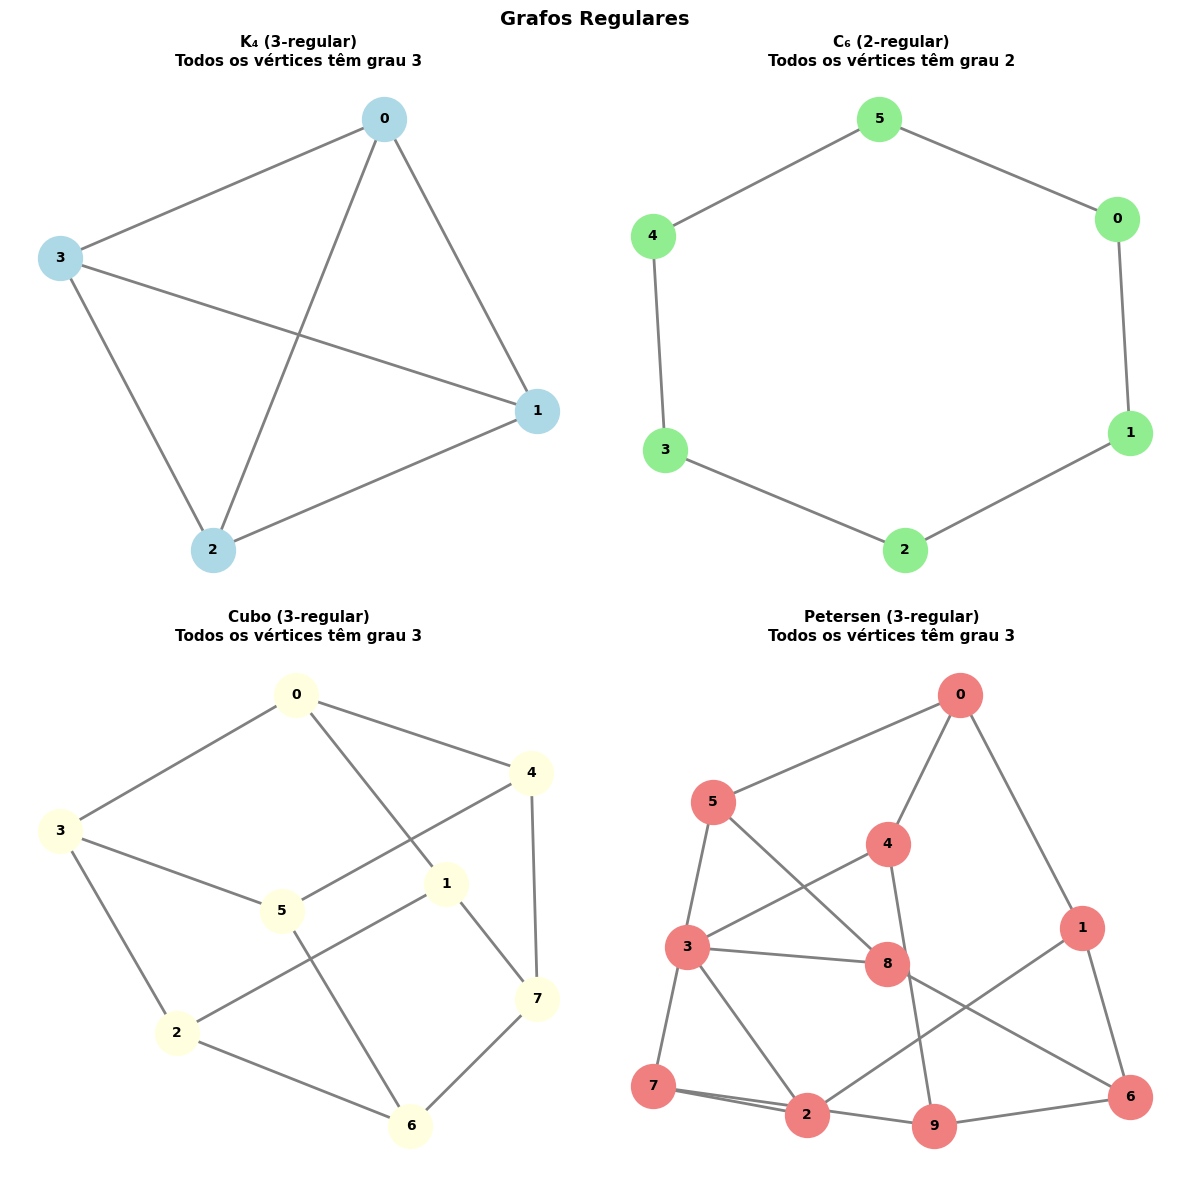

Verificação de regularidade:
  K₄ (3-regular): 3-regular ✓
  C₆ (2-regular): 2-regular ✓
  Cubo (3-regular): 3-regular ✓
  Petersen (3-regular): 3-regular ✓


In [15]:
# Exemplos de grafos regulares
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

grafos_regulares = [
    ("K₄ (3-regular)", nx.complete_graph(4), 'lightblue'),
    ("C₆ (2-regular)", nx.cycle_graph(6), 'lightgreen'),
    ("Cubo (3-regular)", nx.cubical_graph(), 'lightyellow'),
    ("Petersen (3-regular)", nx.petersen_graph(), 'lightcoral')
]

for i, (nome, G, cor) in enumerate(grafos_regulares):
    graus = dict(G.degree())
    grau_comum = list(graus.values())[0]
    
    if i == 2:  # Cubo
        pos = nx.spring_layout(G, seed=42, k=1.5)
    else:
        pos = nx.spring_layout(G, seed=42)
    
    nx.draw(G, pos, ax=axes[i],
            with_labels=True,
            node_color=cor,
            node_size=1000,
            font_size=10,
            font_weight='bold',
            edge_color='gray',
            width=2)
    
    axes[i].set_title(f"{nome}\nTodos os vértices têm grau {grau_comum}", 
                     fontsize=11, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Grafos Regulares', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("Verificação de regularidade:")
for nome, G, _ in grafos_regulares:
    graus = list(dict(G.degree()).values())
    eh_regular = len(set(graus)) == 1
    grau = graus[0] if eh_regular else None
    print(f"  {nome}: {grau}-regular ✓" if eh_regular else f"  {nome}: Não regular")

---

## 7. Exercícios Práticos

🎯 EXERCÍCIO: Analise o grafo e responda



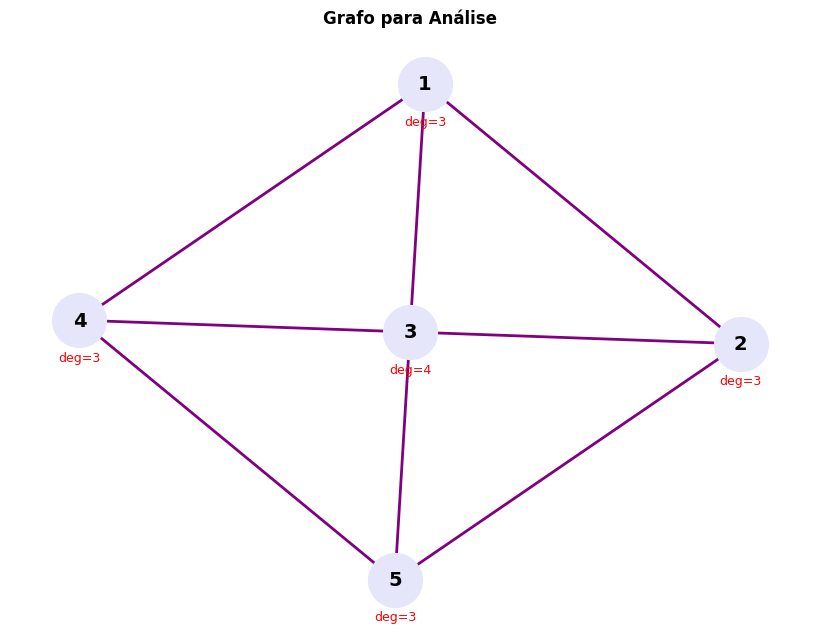

Perguntas:
1. Qual o grau de cada vértice?
2. Qual o grau total do grafo?
3. Quantas arestas o grafo possui?
4. Quantos vértices de grau ímpar existem?
5. O grafo é regular?

RESPOSTAS:
1. Graus: {1: 3, 2: 3, 3: 4, 4: 3, 5: 3}
2. Grau total: 16
3. Número de arestas: 8 (= 16/2)
4. Vértices de grau ímpar: [1, 2, 4, 5] → 4 vértices
5. Regular: False


In [16]:
# Exercício: Analisar um grafo
print("🎯 EXERCÍCIO: Analise o grafo e responda\n")

G_exerc = nx.Graph()
G_exerc.add_edges_from([
    (1, 2), (1, 3), (1, 4),
    (2, 3), (2, 5),
    (3, 4), (3, 5),
    (4, 5)
])

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_exerc, seed=42)
graus = dict(G_exerc.degree())

nx.draw(G_exerc, pos,
        with_labels=True,
        node_color='lavender',
        node_size=1500,
        font_size=14,
        font_weight='bold',
        edge_color='purple',
        width=2)

labels_grau = {v: f"deg={graus[v]}" for v in G_exerc.nodes()}
pos_labels = {k: (v[0], v[1]-0.15) for k, v in pos.items()}
nx.draw_networkx_labels(G_exerc, pos_labels, labels_grau, font_size=9, font_color='red')

plt.title('Grafo para Análise', fontweight='bold')
plt.axis('off')
plt.show()

print("Perguntas:")
print("1. Qual o grau de cada vértice?")
print("2. Qual o grau total do grafo?")
print("3. Quantas arestas o grafo possui?")
print("4. Quantos vértices de grau ímpar existem?")
print("5. O grafo é regular?")

print("\n" + "="*60)
print("RESPOSTAS:")
print("="*60)
print(f"1. Graus: {graus}")
soma_graus = sum(graus.values())
print(f"2. Grau total: {soma_graus}")
num_arestas = G_exerc.number_of_edges()
print(f"3. Número de arestas: {num_arestas} (= {soma_graus}/2)")
graus_impares = [v for v, g in graus.items() if g % 2 == 1]
print(f"4. Vértices de grau ímpar: {graus_impares} → {len(graus_impares)} vértices")
eh_regular = len(set(graus.values())) == 1
print(f"5. Regular: {eh_regular}")

---

## 📌 Resumo

### Conceitos Fundamentais:

1. **Grau de vértice**: Número de arestas incidentes (laços contam 2×)
2. **Teorema do Aperto de Mãos**: $\sum \deg(v) = 2|E|$
3. **Vértices de grau ímpar**: Sempre em número PAR
4. **Grafo regular**: Todos os vértices têm o mesmo grau

### Aplicações:
- ✅ Verificar se um conjunto de graus pode formar um grafo
- ✅ Calcular número mínimo de arestas
- ✅ Analisar estrutura e propriedades de redes

### 🎯 Próximo notebook:
**06_konigsberg.ipynb** - O histórico Problema das Sete Pontes de Königsberg